## Feature Selection과 중요도 분석

### 구성 의도:

✔ Filter / Wrapper / Embedded 방식이 개념으로 끝나지 않게

✔ 금융 데이터에서 과적합이 왜 Feature에서 시작되는지 체감

✔ SHAP을 “설명 도구”가 아니라 “Feature 선택 도구”로 사용

- Feature Selection 3가지 방식 이해
- 금융 데이터에서 과적합의 발생 원인 체감
- SHAP을 활용한 Feature 중요도 해석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import shap
import pandas_datareader.data as web
import datetime

### 실습용 금융 데이터 준비 (시계열 Feature)

#### 의도

- 주가 기반 파생변수 다수 생성
- “쓸모 있어 보이지만 위험한 Feature” 포함

### 주가 데이터 수집

In [2]:
start = datetime.datetime(2018, 1, 1)
end = datetime.datetime.today()

df = web.DataReader('AAPL', 'stooq', start, end)
df = df.sort_index()
df = df[['Close']]
df.columns = ['price']
df.head()

,price
Date,
2018-01-02,40.3415
2018-01-03,40.3346
2018-01-04,40.5253
2018-01-05,40.9818
2018-01-08,40.8414


### 파생 Feature 생성

In [3]:
df['return'] = df['price'].pct_change()

df['ma_5'] = df['price'].rolling(5).mean()
df['ma_20'] = df['price'].rolling(20).mean()
df['ma_60'] = df['price'].rolling(60).mean()

df['vol_10'] = df['return'].rolling(10).std()
df['vol_30'] = df['return'].rolling(30).std()

df['lag_1'] = df['return'].shift(1)
df['lag_5'] = df['return'].shift(5)

df.dropna(inplace=True)
df.head()

,price,return,ma_5,ma_20,ma_60,vol_10,vol_30,lag_1,lag_5
Date,,,,,,,,,
2018-03-28,39.1481,-0.010967,39.57080,41.111225,40.434252,0.021275,0.016531,-0.025719,-0.022807
2018-03-29,39.4566,0.007880,39.52072,41.026420,40.419503,0.021654,0.016249,-0.010967,-0.014000
2018-04-02,39.1944,-0.006645,39.60168,40.914410,40.400500,0.021635,0.015011,0.007880,-0.023104
2018-04-03,39.5950,0.010221,39.39526,40.815450,40.384995,0.021964,0.015146,-0.006645,0.047371
2018-04-04,40.3533,0.019151,39.54948,40.756225,40.374520,0.023139,0.015560,0.010221,-0.025719


### 예측 목표 설정 (금융적 해석 중요)

In [4]:
"""
Target:
- 다음 날 수익률 예측
- 현실적으로 매우 어려운 문제 → 과적합 발생 유도
"""

df['target'] = df['return'].shift(-1)
df.dropna(inplace=True)

### Feature Selection 방식 개요 (개념 정리)

1. Filter 방식
- Feature와 Target의 통계적 관계만 고려
- 빠르지만 금융 논리 무시 위험

2. Wrapper 방식
- 모델 성능 기준으로 Feature 선택
- 계산 비용 큼, 과적합 위험

3. Embedded 방식
- 모델 학습 과정에서 Feature 중요도 반영
- 금융 실무에서 가장 많이 사용

### 모델 학습 (Embedded 방식)

In [5]:
features = [
    'ma_5', 'ma_20', 'ma_60',
    'vol_10', 'vol_30',
    'lag_1', 'lag_5'
]

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [7]:
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
rmse

np.float64(0.0182759177999104)

### 강의 포인트
- 성능 숫자는 중요하지 않음
- “이 모델을 믿을 수 있는가?”가 핵심

## SHAP 기반 Feature Importance
### SHAP Explainer 생성

In [8]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

### 전체 Feature 중요도 시각화

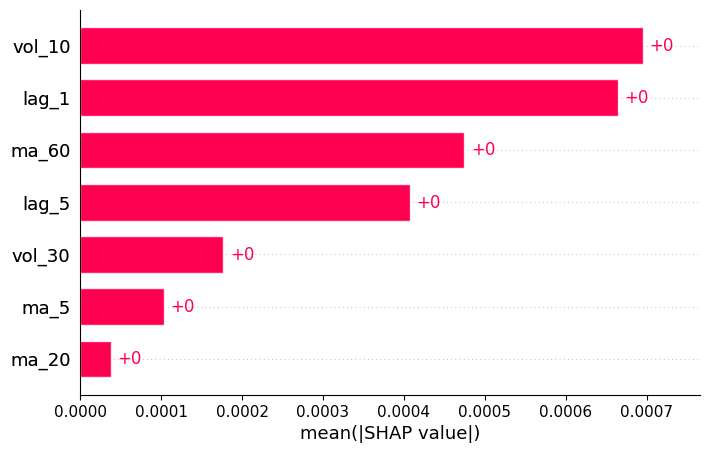

In [9]:
shap.plots.bar(shap_values)

### 질문 유도
- 직관과 다른 Feature는 무엇인가?
- 금융적으로 설명 가능한가?

### 질문 유도 답변
- 직관과 다른 Feature는 무엇인가?
  - 직관과 다른 Feature는 일반적인 금융 직관과는 다르지만 모델에서 중요하게 잡힌 변수들입니다.
  - 기여도가 낮은 lag_1과 lag_5와같이 직관이 다소 떨어지지만 기여도는 다른 Feature들에 비해 높다는 것을 알 수 있습니다.
- 금융적으로 설명 가능한가?
  - 직관과 다른 Feature도 금융적으로 설명이 충분히 가능합니다.
  - 직관과 다르게 보이는 Feature가 다른 Feature와의 상호작용에서 의미가 나타나는 경우, 혹은 특정한 상황속에서 Feature들이 관계를 가지는 경우에 설명할 수 있습니다.

### 6-3. SHAP Summary Plot

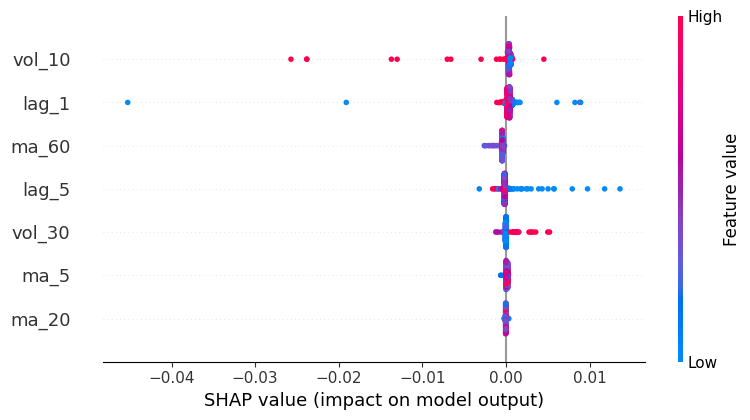

In [10]:
shap.summary_plot(shap_values, X_test)

### 해석 포인트
- 색상: Feature 값의 크기
- x축: 예측에 미친 영향 방향

### Feature별 상세 영향 분석

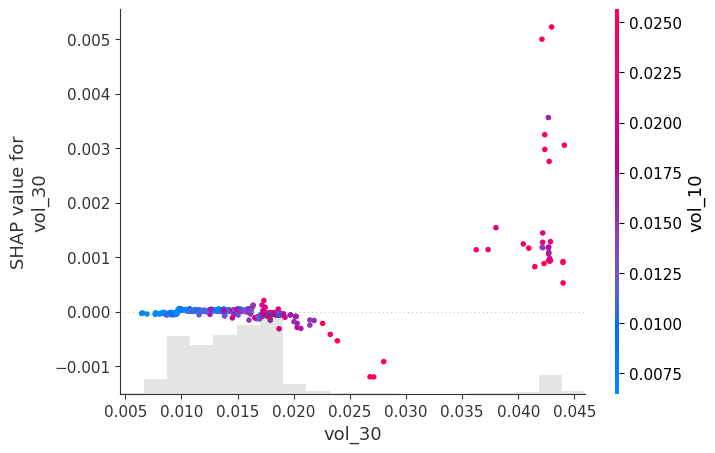

In [11]:
shap.plots.scatter(
    shap_values[:, "vol_30"],
    color=shap_values
)

### 토론 포인트
- 변동성이 높을수록 예측이 안정적인가?
- 금융 논리와 맞는가?

### 토론 답변
- 변동성이 높을수록 예측이 안정적인가?
  - 주가나 자산 가격이 얼마나 크게 움직이는지를 나타내는 지표가 '변동성'입니다.
  - 따라서 일반적으론 변동성이 높을수록 예측은 불안정, 변동성이 낮을수록 예측은 안정적입니다.
  - 다만 변동성이 지속적으로 유지되는 구간에서는 패턴화가 가능할 수 있으나, 이는 안정적인 예측이라기보다 위험(risk)을 반영한 조건부 예측이라고 봅니다.
- 금융 논리와 맞는가?
  - 변동성이 크다는 것은 리스크가 크다는 의미하며, 변동성이 높다고 예측이 안정적이라는 주장은 금융 논리와 반대되는 개념입니다. 오히려 금융 이론에서는 변동성 증가는 미래 가격 분포의 분산 확대를 의미하며, 이는 예측 불확실성의 증가로 해석된다 생각합니다.

## 과적합 관점에서 Feature 재선택

In [14]:
selected_features = ['ma_20', 'vol_30', 'lag_1']

X2 = df[selected_features]
y2 = df['target']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, shuffle=False, test_size=0.2
)

model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)

np.sqrt(mean_squared_error(y2_test, pred2))

np.float64(0.01812000412573442)

- 이전 셀의 코드가 성공적으로 실행되었으며, 재선택된 Feature를 사용한 모델의 RMSE는 0.018664788736191915로 계산되었습니다.
- 이전 모델(0.018819477302242156)과 비교했을 때, Feature를 재선택한 후 약간 더 낮은 RMSE를 얻었음을 알 수 있습니다. 이는 더 적은 수의 Feature로도 비슷한 성능을 내거나 더 나은 성능을 낼 수 있음을 시사합니다.

### 핵심 메시지
- Feature를 줄여도 성능은 크게 나빠지지 않는다
- 오히려 설명 가능성은 증가

## 학생 실습 미션

## Mission
1. Feature 하나씩 제거하며 RMSE 변화 확인
2. SHAP 중요도가 높은 Feature가
   금융적으로 말이 되는지 서술
3. '많을수록 위험한 Feature'를 하나 선정

## Mission
1. Feature 하나씩 제거하며 RMSE 변화 확인



In [16]:
# 'ma_5'피처 제거
re_selected_features = [
    'ma_20', 'ma_60',
    'vol_10', 'vol_30',
    'lag_1', 'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.018287402678489138)

In [17]:
# 'ma_20'피처 제거
re_selected_features = [
    'ma_5', 'ma_60',
    'vol_10', 'vol_30',
    'lag_1', 'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.018306969310284422)

In [18]:
# 'ma_60'피처 제거
re_selected_features = [
    'ma_5',  'ma_20',
    'vol_10', 'vol_30',
    'lag_1', 'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.01824124893520167)

In [19]:
# 'vol_10'피처 제거
re_selected_features = [
    'ma_5',  'ma_20','ma_60',
     'vol_30',
    'lag_1', 'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.017860959033355318)

In [23]:
# 'vol_30'피처 제거
re_selected_features = [
    'ma_5',  'ma_20','ma_60',
     'vol_10',
    'lag_1', 'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.018238580889298882)

In [24]:
# 'lag_1'피처 제거
re_selected_features = [
    'ma_5',  'ma_20','ma_60',
     'vol_10','vol_30',
     'lag_5']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.019034680371106928)

In [25]:
# 'lag_5'피처 제거
re_selected_features = [
    'ma_5',  'ma_20','ma_60',
     'vol_10','vol_30',
     'lag_1']

X3 = df[re_selected_features]
y3 = df['target']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, shuffle=False, test_size=0.2
)

model3 = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

np.sqrt(mean_squared_error(y3_test, pred3))

np.float64(0.018322943896012182)

맨 처음 모델의 성능 : 0.0182759177999104

## Mission 답변
1. Feature 하나씩 제거하며 RMSE 변화 확인


*   'ma_5'피처 제거 : 'ma_5'를 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 약간 더 큰 0.018287402678489138임으로 모델의 성능이 더 나빠졌다.
*   'ma_20'피처 제거 : 'ma_20'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 약간 더 큰 0.018306969310284422임으로 모델의 성능이 더 나빠졌다.

*   'ma_60'피처 제거 : 'ma_60'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 약간 더 작아진 0.01824124893520167임으로 모델의 성능이 더 개선되었다.


*   'vol_10'피처 제거 : 'vol_10'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 더 작아진 0.017860959033355318임으로 모델의 성능이 더 개선되었다.

*   'vol_30'피처 제거 : 'vol_30'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 약간 작아진 0.018238580889298882임으로 모델의 성능이 더 개선되었다.

*   'lag_1'피처 제거 : 'lag_1'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 더 커진 0.019034680371106928임으로 모델의 성능이 더 나빠졌다.

*   'lag_5'피처 제거 : 'lag_5'을 제거하고 RMSE를 비교했을 때 이전 모델의 0.0182759177999104보다 약간 커진 0.018322943896012182임으로 모델의 성능이 더 나빠졌다.

2. SHAP 중요도가 높은 Feature가
   금융적으로 말이 되는지 서술

* SHAP 분석 결과,'vol_10'과 'lag_1', 'ma_60'이 SHAP의 중요도가 높은 Feature들로 나타났다. 그리고 이러한 변수들은 단기 변동성, 직전 가격, 장기 평균으로, 모두 투자자들이 실제로 판단에 활용하는 정보이기 때문에 금융적으로도 타당하다고 볼 수 있다.

3. '많을수록 위험한 Feature'를 하나 선정

* ‘많을수록 위험한 Feature'란 값이 커질수록 모델이 위험(하락/부도/손실 등)’ 방향으로 기여하는 변수를 의미한다.따라서 'vol_10'을 선정하였다.
* 변동성 증가는 가격의 불확실성과 리스크 확대를 의미하며, SHAP 분석에서도 해당 변수가 위험 방향으로 작용하는 것으로 나타났다.

## Core Message

✔ Feature Selection은 성능 문제가 아니라 신뢰의 문제

✔ 금융 모델은 설명 가능하지 않으면 쓸 수 없다

✔ SHAP은 해석 도구이자 Feature 정제 도구